In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_csv_path = "results.csv"
results_df = pd.read_csv(results_csv_path)

headers = results_df.columns.tolist()
num_boulders = len([h for h in headers if h.startswith("Boulder")])

boulder_total_tops = np.zeros(num_boulders, dtype=int)
boulder_total_zones = np.zeros(num_boulders, dtype=int)
boulder_total_top_attempts = np.zeros(num_boulders, dtype=int)
boulder_total_zone_attempts = np.zeros(num_boulders, dtype=int)
num_competitors = len(results_df)

for idx, row in results_df.iterrows():
	for i in range(num_boulders):
		boulder_result = row[f"Boulder {i+1}"]
		if pd.isna(boulder_result):
			continue

		# boulder_result is expected to be in the format "B{boulder_number} T{top}Z{zone}", e.g. "B2 T1Z2"

		parts = boulder_result.split(" ")
		if len(parts) != 2:
			continue

		attempt_data_part = parts[1]

		# First part is the boulder number, second part contains top and zone information
		top_part, zone_part = attempt_data_part[:2], attempt_data_part[2:]
		top_attempts = int(top_part[1:])
		zone_attempts = int(zone_part[1:])

		top_score = 1 if top_attempts > 0 else 0
		zone_score = 1 if zone_attempts > 0 else 0

		boulder_total_tops[i] += top_score
		boulder_total_zones[i] += zone_score
		boulder_total_top_attempts[i] += top_attempts
		boulder_total_zone_attempts[i] += zone_attempts

boulder_indices = np.arange(0, num_boulders)

# Sort boulders by total tops, then total zones, then total top attempts, then total zone attempts
boulder_indices_sorted_by_difficulty = np.lexsort((
	boulder_total_zone_attempts,
	boulder_total_top_attempts,
	-boulder_total_zones,
	-boulder_total_tops
))

print("Boulder difficulty ranking (easiest to hardest):")
for rank, idx in enumerate(boulder_indices_sorted_by_difficulty):
	print(f"Rank {rank+1}: Boulder {idx+1} - Tops: {boulder_total_tops[idx]}, Zones: {boulder_total_zones[idx]}, Top Attempts: {boulder_total_top_attempts[idx]}, Zone Attempts: {boulder_total_zone_attempts[idx]}")

Boulder difficulty ranking (easiest to hardest):
Rank 1: Boulder 20 - Tops: 35, Zones: 35, Top Attempts: 37, Zone Attempts: 37
Rank 2: Boulder 14 - Tops: 35, Zones: 35, Top Attempts: 45, Zone Attempts: 45
Rank 3: Boulder 16 - Tops: 34, Zones: 35, Top Attempts: 36, Zone Attempts: 36
Rank 4: Boulder 8 - Tops: 33, Zones: 35, Top Attempts: 33, Zone Attempts: 35
Rank 5: Boulder 19 - Tops: 31, Zones: 31, Top Attempts: 51, Zone Attempts: 45
Rank 6: Boulder 4 - Tops: 23, Zones: 28, Top Attempts: 41, Zone Attempts: 38
Rank 7: Boulder 2 - Tops: 21, Zones: 25, Top Attempts: 50, Zone Attempts: 58
Rank 8: Boulder 12 - Tops: 21, Zones: 24, Top Attempts: 57, Zone Attempts: 56
Rank 9: Boulder 1 - Tops: 13, Zones: 23, Top Attempts: 31, Zone Attempts: 39
Rank 10: Boulder 10 - Tops: 12, Zones: 16, Top Attempts: 33, Zone Attempts: 38
Rank 11: Boulder 17 - Tops: 11, Zones: 21, Top Attempts: 27, Zone Attempts: 57
Rank 12: Boulder 6 - Tops: 11, Zones: 19, Top Attempts: 17, Zone Attempts: 33
Rank 13: Boulder 

In [ ]:
boulder_top_rates = boulder_total_tops / num_competitors
boulder_zone_rates = boulder_total_zones / num_competitors
boulder_avg_top_attempts = boulder_total_top_attempts / boulder_total_tops
boulder_avg_zone_attempts = boulder_total_zone_attempts / boulder_total_zones


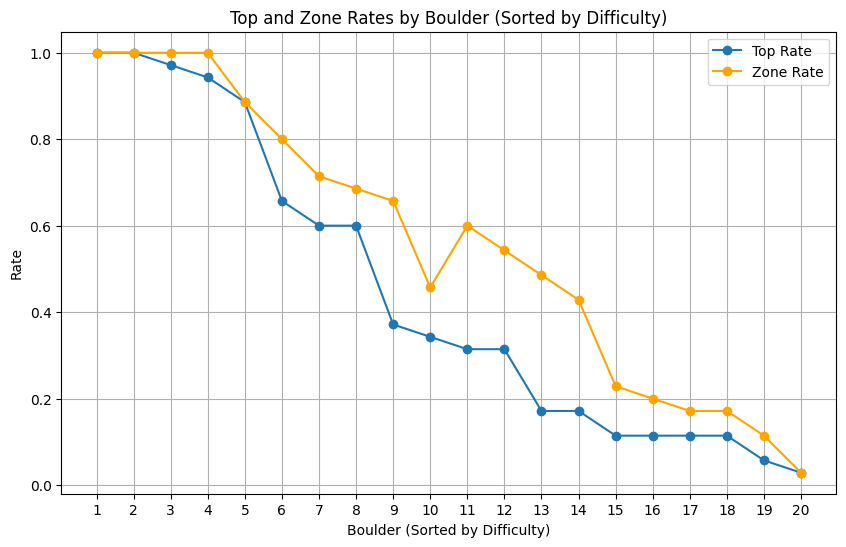

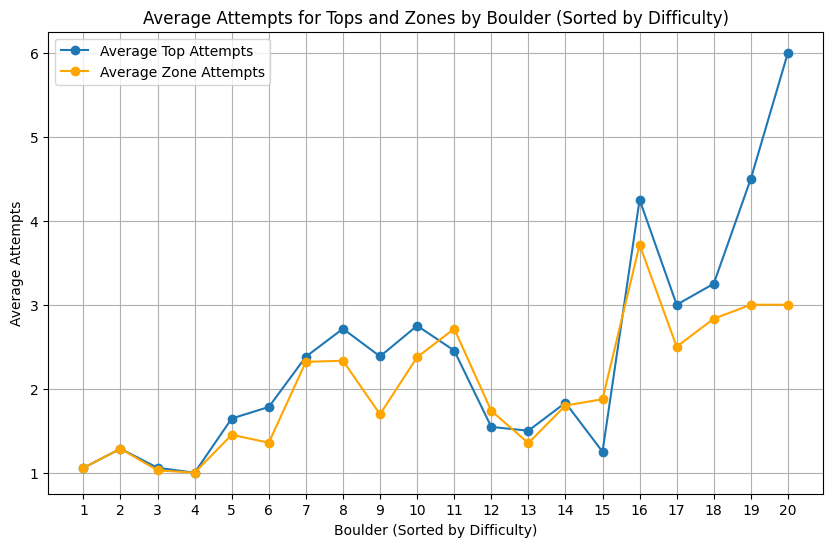

In [23]:
# First plot, sorted top rate by difficulty
boulder_top_rates_sorted = boulder_total_tops[boulder_indices_sorted_by_difficulty] / num_competitors
boulder_zone_rates_sorted = boulder_total_zones[boulder_indices_sorted_by_difficulty] / num_competitors
plt.figure(figsize=(10, 6))
plt.plot(boulder_indices + 1, boulder_top_rates_sorted, marker='o')
plt.plot(boulder_indices + 1, boulder_zone_rates_sorted, marker='o', color='orange')
plt.title("Top and Zone Rates by Boulder (Sorted by Difficulty)")
plt.xlabel("Boulder (Sorted by Difficulty)")
plt.ylabel("Rate")
plt.legend(["Top Rate", "Zone Rate"])
plt.xticks(boulder_indices_sorted_by_difficulty + 1)
plt.grid()
plt.show()

# Second plot, average attempts for tops and zones by difficulty
boulder_avg_top_attempts_sorted = boulder_total_top_attempts[boulder_indices_sorted_by_difficulty] / boulder_total_tops[boulder_indices_sorted_by_difficulty]
boulder_avg_zone_attempts_sorted = boulder_total_zone_attempts[boulder_indices_sorted_by_difficulty] / boulder_total_zones[boulder_indices_sorted_by_difficulty]
plt.figure(figsize=(10, 6))
plt.plot(boulder_indices + 1, boulder_avg_top_attempts_sorted, marker='o')
plt.plot(boulder_indices + 1, boulder_avg_zone_attempts_sorted, marker='o', color='orange')
plt.title("Average Attempts for Tops and Zones by Boulder (Sorted by Difficulty)")
plt.xlabel("Boulder (Sorted by Difficulty)")
plt.ylabel("Average Attempts")
plt.legend(["Average Top Attempts", "Average Zone Attempts"])
plt.xticks(boulder_indices_sorted_by_difficulty + 1)
plt.grid()
plt.show()